In [1]:
#Exploratory Data Analysis

In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [3]:
sns.set_theme(style='whitegrid')

In [4]:
#Load Data
df=pd.read_csv(r'D:\202-2026bootcampproject\Python DataCleaning Output File.csv')

In [9]:
df.dtypes

Invoice                int64
StockCode             object
Description           object
Quantity               int64
InvoiceDate           object
Price                float64
Customer ID            int64
Country               object
Order_Status          object
Invoice_Date_Only     object
Week_Beginning        object
dtype: object

In [10]:
df['InvoiceDate']      = pd.to_datetime(df['InvoiceDate'])
df['Invoice_Date_Only'] = pd.to_datetime(df['Invoice_Date_Only'])
df['Week_Beginning']    = pd.to_datetime(df['Week_Beginning'])

In [11]:
df['Revenue'] = df['Quantity'] * df['Price']

In [12]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Order_Status,Invoice_Date_Only,Week_Beginning,Revenue
0,539708,35924,Hanging Fairy Cake Decoration,1,2010-12-21 12:18:00,4.21,0,United Kingdom,Completed,2010-12-21,2010-12-20,4.21
1,539246,85114C,Red Enchanted Forest Placemat,8,2010-12-16 13:33:00,1.65,14606,United Kingdom,Completed,2010-12-16,2010-12-13,13.20
2,536415,22910,Paper Chain Kit Vintage Christmas,5,2010-12-01 11:57:00,2.95,12838,United Kingdom,Completed,2010-12-01,2010-11-29,14.75
3,537254,20975,12 Pencils Small Tube Red Retrospot,4,2010-12-06 11:01:00,0.65,15898,United Kingdom,Completed,2010-12-06,2010-12-06,2.60
4,538864,21485,Retrospot Heart Hot Water Bottle,24,2010-12-14 14:26:00,4.25,17739,United Kingdom,Completed,2010-12-14,2010-12-13,102.00


In [13]:
df['InvoiceHour'] = df['InvoiceDate'].dt.hour

In [14]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Order_Status,Invoice_Date_Only,Week_Beginning,Revenue,InvoiceHour
0,539708,35924,Hanging Fairy Cake Decoration,1,2010-12-21 12:18:00,4.21,0,United Kingdom,Completed,2010-12-21,2010-12-20,4.21,12
1,539246,85114C,Red Enchanted Forest Placemat,8,2010-12-16 13:33:00,1.65,14606,United Kingdom,Completed,2010-12-16,2010-12-13,13.20,13
2,536415,22910,Paper Chain Kit Vintage Christmas,5,2010-12-01 11:57:00,2.95,12838,United Kingdom,Completed,2010-12-01,2010-11-29,14.75,11
3,537254,20975,12 Pencils Small Tube Red Retrospot,4,2010-12-06 11:01:00,0.65,15898,United Kingdom,Completed,2010-12-06,2010-12-06,2.60,11
4,538864,21485,Retrospot Heart Hot Water Bottle,24,2010-12-14 14:26:00,4.25,17739,United Kingdom,Completed,2010-12-14,2010-12-13,102.00,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9969,539760,15036,Assorted Colours Silk Fan,12,2010-12-21 17:16:00,0.75,17400,United Kingdom,Completed,2010-12-21,2010-12-20,9.00,17
9970,537827,22145,Christmas Craft Heart Stocking,30,2010-12-08 14:43:00,2.10,15332,Lithuania,Completed,2010-12-08,2010-12-06,63.00,14
9971,536864,21488,Red White Scarf Hot Water Bottle,1,2010-12-03 11:27:00,8.47,0,United Kingdom,Completed,2010-12-03,2010-11-29,8.47,11
9972,538153,82599,Fanny'S Rest Stopmetal Sign,1,2010-12-09 16:31:00,4.21,0,United Kingdom,Completed,2010-12-09,2010-12-06,4.21,16


In [16]:
Completed = df[df['Order_Status']=='Completed'].copy()

In [ ]:
#Dataset Overview

In [20]:
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
# .shape gives (number of rows, number of columns)
print(f"Shape             : {df.shape[0]:,} rows × {df.shape[1]} columns")
 
# .min() and .max() on a date column give us the earliest and latest dates
print(f"Date range        : {df['InvoiceDate'].min().date()}  →  {df['InvoiceDate'].max().date()}")
 
# .nunique() counts how many unique values exist in a column
print(f"Unique invoices   : {df['Invoice'].nunique():,}")
print(f"Unique customers  : {df['Customer ID'].nunique():,}")
print(f"Unique products   : {df['StockCode'].nunique():,}")
 
# value_counts() shows how many rows belong to each category
print(f"\nOrder status counts:\n{df['Order_Status'].value_counts()}")
 
# isnull().sum() counts missing values in each column
print(f"\nMissing values per column:\n{df.isnull().sum()}")

DATASET OVERVIEW
Shape             : 9,974 rows × 13 columns
Date range        : 2010-12-01  →  2010-12-23
Unique invoices   : 1,436
Unique customers  : 833
Unique products   : 2,032

Order status counts:
Order_Status
Completed    9821
Cancelled     153
Name: count, dtype: int64

Missing values per column:
Invoice              0
StockCode            0
Description          0
Quantity             0
InvoiceDate          0
Price                0
Customer ID          0
Country              0
Order_Status         0
Invoice_Date_Only    0
Week_Beginning       0
Revenue              0
InvoiceHour          0
dtype: int64


In [21]:
#1 — DISTRIBUTIONS OF QUANTITY AND PRICE
# We want to understand the typical range of quantity and price values.
# Are most orders for 1-2 items? Are prices mostly low or spread out?
# A histogram shows us how values are distributed across the range.

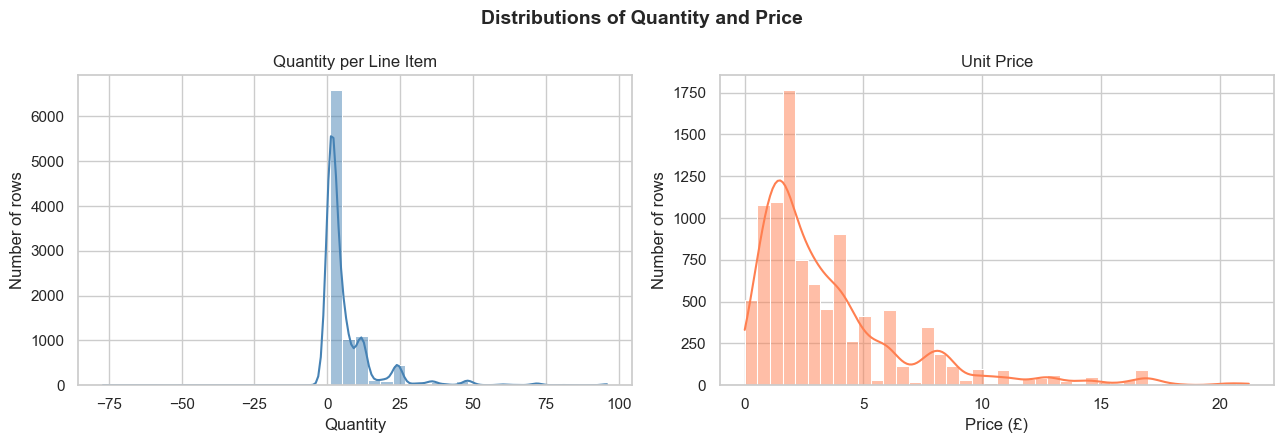

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Distributions of Quantity and Price', fontsize=14, fontweight='bold')

q99 = Completed['Quantity'].quantile(0.99)
quantity_filtered = Completed[Completed['Quantity'] <= q99]['Quantity']
sns.histplot(quantity_filtered, bins=40, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Quantity per Line Item')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Number of rows')

p99 = Completed['Price'].quantile(0.99)
price_filtered = Completed[Completed['Price'] <= p99]['Price']
sns.histplot(price_filtered, bins=40, kde=True, color='coral', ax=axes[1])
axes[1].set_title('Unit Price')
axes[1].set_xlabel('Price (£)')
axes[1].set_ylabel('Number of rows')

plt.tight_layout()
plt.show()

In [45]:
plt.tight_layout()                                        
plt.savefig('Distributions of Quantity and Price.png', bbox_inches='tight') 
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
print("Skewness Quality:",round(Completed['Quantity'].skew(),2))
print("Skewness Price:",round(Completed['Price'].skew(),2))

In [46]:
#2 — ORDER STATUS BREAKDOWN
#What share of all orders were completed vs cancelled?
#And how much revenue came from each status?
#This gives us a high-level picture of order health.

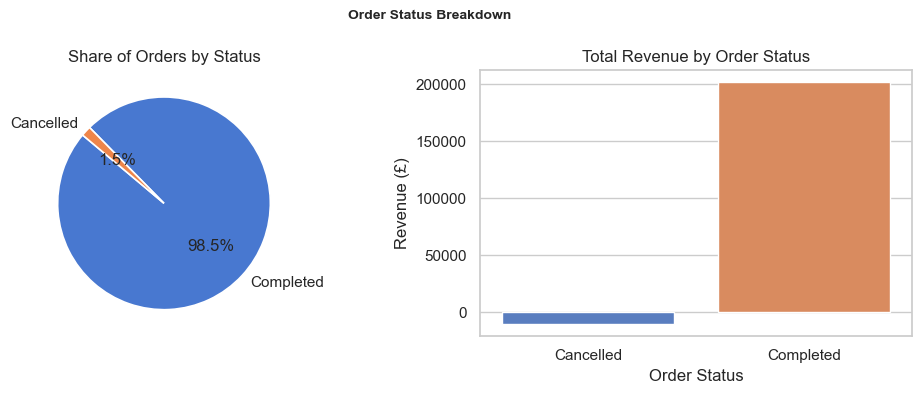

In [54]:
fig, axes=plt.subplots(1,2,figsize=(10,4))
fig.suptitle('Order Status Breakdown', fontsize=10,fontweight='bold')

status_counts=df['Order_Status'].value_counts()
status_revenue=df.groupby('Order_Status')['Revenue'].sum()

axes[0].pie(status_counts,labels=status_counts.index,autopct='%1.1f%%',
            colors=sns.color_palette('muted',len(status_counts)),startangle=140,wedgeprops={'edgecolor':'white','linewidth':1.2})
axes[0].set_title('Share of Orders by Status')

sns.barplot(x=status_revenue.index, y=status_revenue.values, palette='muted', ax=axes[1])
axes[1].set_title('Total Revenue by Order Status')
axes[1].set_xlabel('Order Status')
axes[1].set_ylabel('Revenue (£)')

plt.tight_layout()
plt.savefig('Order Status.png',bbox_inches='tight')
plt.show()

In [56]:
#3 — HOURLY ORDER DISTRIBUTION
# We want to know: what time of day do most orders happen?
# Knowing peak hours can help with staffing, marketing, or system capacity.

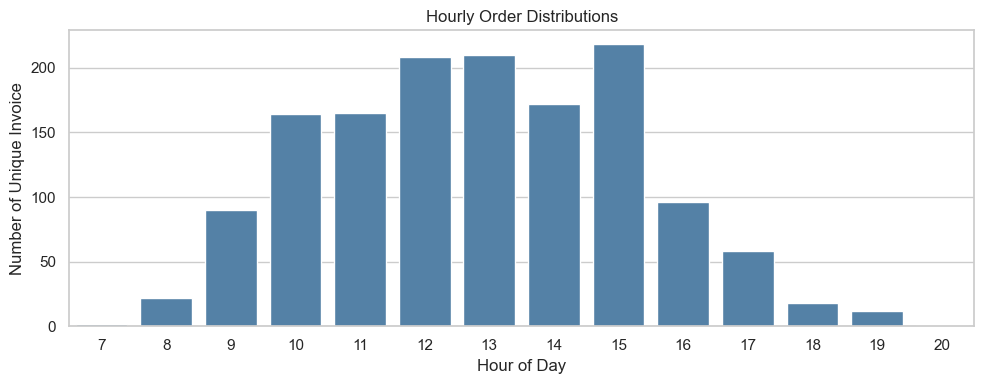


Peak order hour: 15:00


In [66]:
hourly_orders=(df.groupby('InvoiceHour')['Invoice'].nunique().reset_index(name='num_invoices'))

fig, ax=plt.subplots(figsize=(10,4))

sns.barplot(data=hourly_orders,x='InvoiceHour',y='num_invoices',color='steelblue',ax=ax)

ax.set_title('Hourly Order Distributions')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Unique Invoice')

plt.tight_layout()
plt.savefig('Hourly Orders.png', bbox_inches='tight')
plt.show()

peak_hours=hourly_orders.loc[hourly_orders['num_invoices'].idxmax(),'InvoiceHour']
print(f"\nPeak order hour: {peak_hours}:00")

In [ ]:
#4 — ORDERS PER CUSTOMER
# We want to understand customer purchasing behaviour at a high level.
# Do most customers buy only once, or do they come back?
# This is different from RFM — here we just look at the distribution visually.

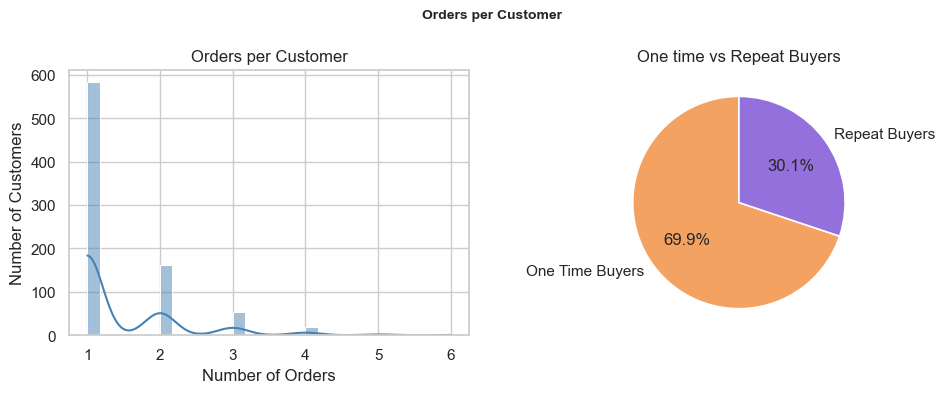


One-time buyers : 582  (69.9%)
Repeat buyers   : 251  (30.1%)


In [72]:
orders_per_customer=(df.groupby('Customer ID')['Invoice'].nunique().reset_index(name='num_orders'))

fig, axes=plt.subplots(1,2,figsize=(10,4))
fig.suptitle('Orders per Customer', fontsize=10, fontweight='bold')

o99=orders_per_customer['num_orders'].quantile(0.99)
orders_filtered=orders_per_customer[orders_per_customer['num_orders']<=o99]['num_orders']

sns.histplot(orders_filtered,bins=30, kde=True, color='steelblue', ax=axes[0])

axes[0].set_title('Orders per Customer')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Number of Customers')

one_time_buyers=(orders_per_customer['num_orders']==1).sum()
repeat_buyers=(orders_per_customer['num_orders']>1).sum()

axes[1].pie([one_time_buyers,repeat_buyers], labels=['One Time Buyers','Repeat Buyers'],autopct='%1.1f%%',colors=['#f4a261', 'mediumpurple'],
            startangle=90,wedgeprops={'edgecolor': 'white', 'linewidth': 1.2})
axes[1].set_title('One time vs Repeat Buyers')

plt.tight_layout()
plt.savefig('One Time vs repeat Buyers.png',bbox_inches='tight')
plt.show()

print(f"\nOne-time buyers : {one_time_buyers:,}  ({one_time_buyers / len(orders_per_customer) * 100:.1f}%)")
print(f"Repeat buyers   : {repeat_buyers:,}  ({repeat_buyers / len(orders_per_customer) * 100:.1f}%)")

In [ ]:
#5 — AVERAGE ORDER VALUE (AOV) DISTRIBUTION
# AOV = total revenue per invoice.
# We want to know: what is a typical order worth?
# Are most orders small (£10-£50) or spread across a wide range?
# Over time — here we look at the VALUE of individual orders.

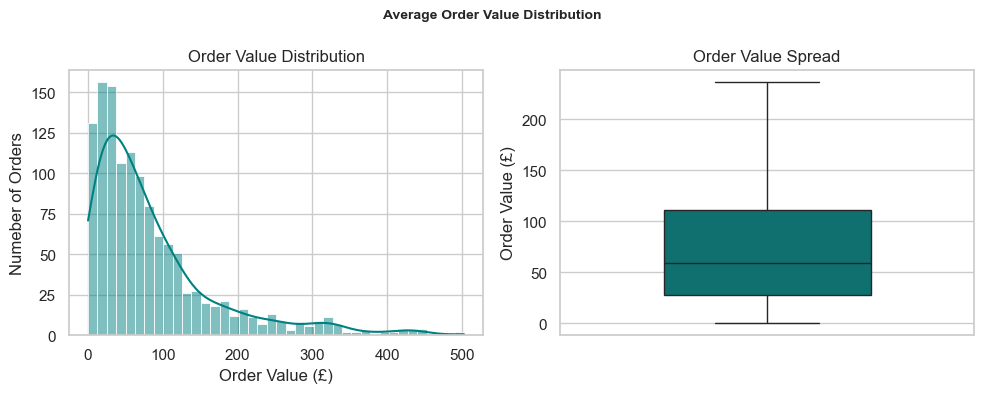


AOV summary statistics:
count     1323.00
mean       152.35
std        493.88
min          0.00
25%         29.62
50%         63.00
75%        122.47
max      13541.33
Name: order_value, dtype: float64


In [77]:
aov=(Completed.groupby('Invoice')['Revenue'].sum().reset_index(name='order_value'))

fig, axes=plt.subplots(1,2,figsize=(10,4))
fig.suptitle('Average Order Value Distribution', fontsize=10, fontweight='bold')

aov_95=aov['order_value'].quantile(0.95)
aov_filtered=aov[aov['order_value']<=aov_95]['order_value']

sns.histplot(aov_filtered, bins=40, kde=True, color='teal', ax=axes[0])

axes[0].set_title('Order Value Distribution')
axes[0].set_xlabel('Order Value (£)')
axes[0].set_ylabel('Numeber of Orders')

sns.boxplot(y=aov_filtered,color='teal', ax=axes[1], width=0.5, showfliers=False)

axes[1].set_title('Order Value Spread')
axes[1].set_ylabel('Order Value (£)')

plt.tight_layout()
plt.savefig('Average Order Distribution.png',bbox_inches='tight')
plt.show()

print("\nAOV summary statistics:")
print(aov['order_value'].describe().round(2))